<a href="https://colab.research.google.com/github/BaltMart/University/blob/main/Year%202/Econometrics/Data_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Martynas Baltramaitis, Ūla Mitkevičiūtė, Dominykas Meškauskas, Adomas Jablonskas

# Task 1

In [ ]:
# Installing packages for robust errors
install.packages('lmtest')
install.packages('sandwich')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘zoo’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Loading libraries
library(dplyr)
library(lmtest)
library(sandwich)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




# a)

In [ ]:
# Setting the seed of reproducibility
set.seed(42)

# Creating a function
generate_data <- function(size_regular_class, size_reduced_class, num_students, rho, delta) {
  # size_regular_class: Number of students in a regular class
  # size_reduced_class: Number of students in a reduced-size class
  # num_students: Number of students in the RCT
  # rho: Intraclass correlation coefficient
  # delta: Treatment effect in standard deviation units

  # Defining the variances of class-specific and student-specific shocks
  var_class <- rho
  var_student <- 1 - rho - (delta ^ 2) / 4

  # Defining the treatment status
  x <- rbinom(n = num_students, size = 1, prob = 0.5)

  # We now separate the students into treatment and control groups
  num_students_t <- sum(x == 1)
  num_students_c <- sum(x == 0)

  # Calculating # of regular classes and assigning IDs
  num_classes_c <- ceiling(num_students_c / size_regular_class)
  class_id_c <- rep(1 : num_classes_c, each = size_regular_class)[1:num_students_c]

  # Calculating # of reduced classes and assigning IDs
  num_classes_t <- ceiling(num_students_t / size_reduced_class)
  class_id_t <- rep((1 : num_classes_t) + num_classes_c, each = size_reduced_class)[1:num_students_t]

  # Combining the class IDs to have a single column
  class_id <- ifelse(x == 0, class_id_c, class_id_t)

  # Class and student specific shocks
  class_shock <- rnorm(n = length(unique(class_id)), mean = 0, sd = sqrt(var_class))
  student_shock <- rnorm(num_students, 0, sqrt(var_student))

  # Generating the test scores
  y <- delta * x + class_shock[class_id] + student_shock

  # Returning the dataset
  dataset <- data.frame(student_id = 1 : num_students, class_id = class_id, y = y, x = x)
  return(dataset)

}

# b)

Theoretical Mean of y: 0.125 
Theoretical Variance of y: 1 
Difference in Mean: 0.01122902 
Difference in Variance: 0.02813774 

	One Sample t-test

data:  simulated_data$y
t = 0.78307, df = 4999, p-value = 0.4336
alternative hypothesis: true mean is not equal to 0.125
95 percent confidence interval:
 0.1081169 0.1643412
sample estimates:
mean of x 
 0.136229 

Chi-Squared Statistic: 5139.661 
p-value for Variance Test: 0.08069436 


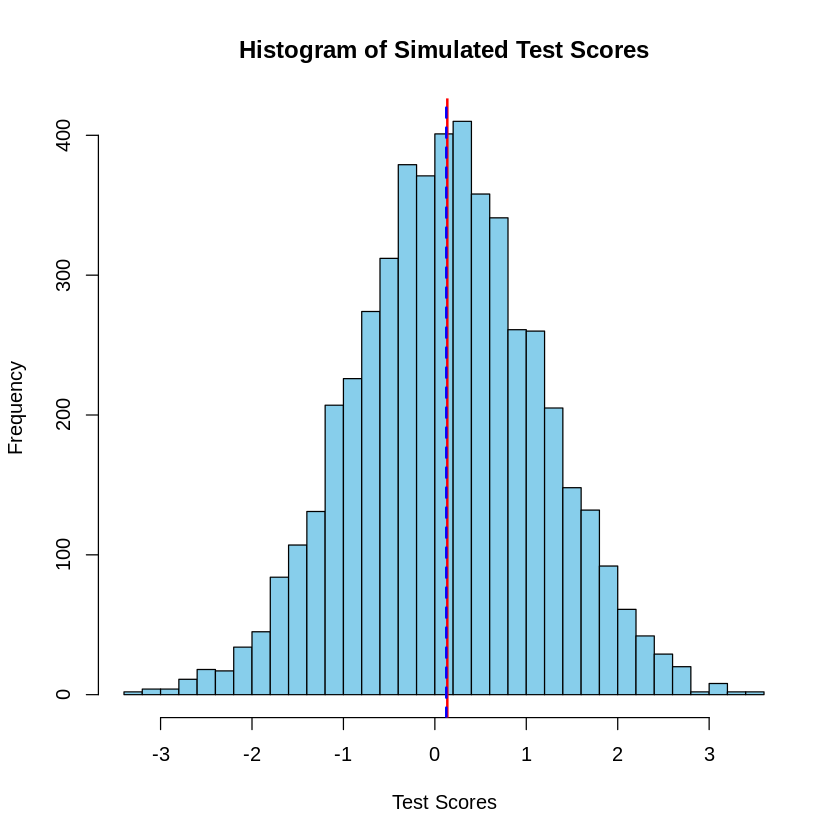

In [ ]:
# Generate the simulated data
set.seed(42)
rho <- 0.2
delta <- 0.25
num_students <- 5000
simulated_data <- generate_data(size_regular_class = 25, size_reduced_class = 18, num_students = num_students, rho = rho, delta = delta)

# Check 1: Mean and Variance
mean_y <- mean(simulated_data$y)
var_y <- var(simulated_data$y)

# Theoretical Mean and Variance
theoretical_mean_y <- delta * 0.5
theoretical_variance_y <- delta^2 * 0.25 + rho + (1 - rho - (delta^2 / 4))
cat("Theoretical Mean of y:", theoretical_mean_y, "\n")
cat("Theoretical Variance of y:", theoretical_variance_y, "\n")

# Check 2: Histogram
hist(simulated_data$y, breaks = 30, main = "Histogram of Simulated Test Scores", xlab = "Test Scores", col = "skyblue")
abline(v = mean_y, col = "red", lwd = 2)
abline(v = theoretical_mean_y, col = "blue", lwd = 2, lty = 2)

# Comparison
cat("Difference in Mean:", abs(mean_y - theoretical_mean_y), "\n")
cat("Difference in Variance:", abs(var_y - theoretical_variance_y), "\n")


t_test_result <- t.test(simulated_data$y, mu = theoretical_mean_y)
print(t_test_result)

chi_squared_statistic <- (num_students - 1) * var_y / theoretical_variance_y
p_value_variance <- 1 - pchisq(chi_squared_statistic, df = num_students - 1)
cat("Chi-Squared Statistic:", chi_squared_statistic, "\n")
cat("p-value for Variance Test:", p_value_variance, "\n")

# c)

In [ ]:
# Generating the dataset with given parameters
set.seed(42)
dataset <- generate_data(25, 18, 5000, 0.2, 0.25)
dataset

student_id,class_id,y,x
<int>,<dbl>,<dbl>,<int>
1,100,-0.07491340,1
2,100,-0.06450770,1
3,1,0.34081935,0
4,100,0.45075587,1
5,100,1.52618532,1
6,100,-0.04052672,1
7,100,1.19965157,1
8,1,-0.28274610,0
9,100,0.52904567,1


In [ ]:
# Running a regression
regression <- lm(y ~ x, data = dataset)

# Computing robust standard errors
coeftest(regression, vcov = vcovHC(regression, type = "HC3"))


t test of coefficients:

            Estimate Std. Error t value  Pr(>|t|)    
(Intercept) 0.023097   0.020323  1.1365    0.2558    
x           0.223934   0.028516  7.8530 4.935e-15 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


# d)

In [ ]:
# i)
set.seed(42) # Reset the seed before the simulation
#Monte Carlo replications
M = 2000

# List of the results
rej_het = numeric(M)

for (i in 1:M){
  df = generate_data(25, 18, 5000, 0.2, 0)
  regress = lm(y ~ x, data = df)
  t_test_het = coeftest(regress, vcov = vcovHC(regress, type = "HC3"))
  rej_het[i] = ifelse(t_test_het["x", "Pr(>|t|)"] < 0.05, 1, 0)
}
rej_het_prob = mean(rej_het)
rej_het_prob


[1] 0.3985

In [ ]:
# ii)
set.seed(42) # Reset the seed before the simulation
#Monte Carlo replications
M = 2000

# List of the results
rej_clus = numeric(M)

for (i in 1:M){
  df = generate_data(25, 18, 5000, 0.2, 0)
  regress = lm(y ~ x, data = df)
  clust_se = vcovCL(regress, cluster = ~ class_id)
  t_test_clus = coeftest(regress, vcov = clust_se)
  rej_clus[i] = ifelse(t_test_clus["x", "Pr(>|t|)"] < 0.05, 1, 0)
}
rej_clus_prob = mean(rej_clus)
rej_clus_prob

[1] 0.058

# e)

[1] 0.967

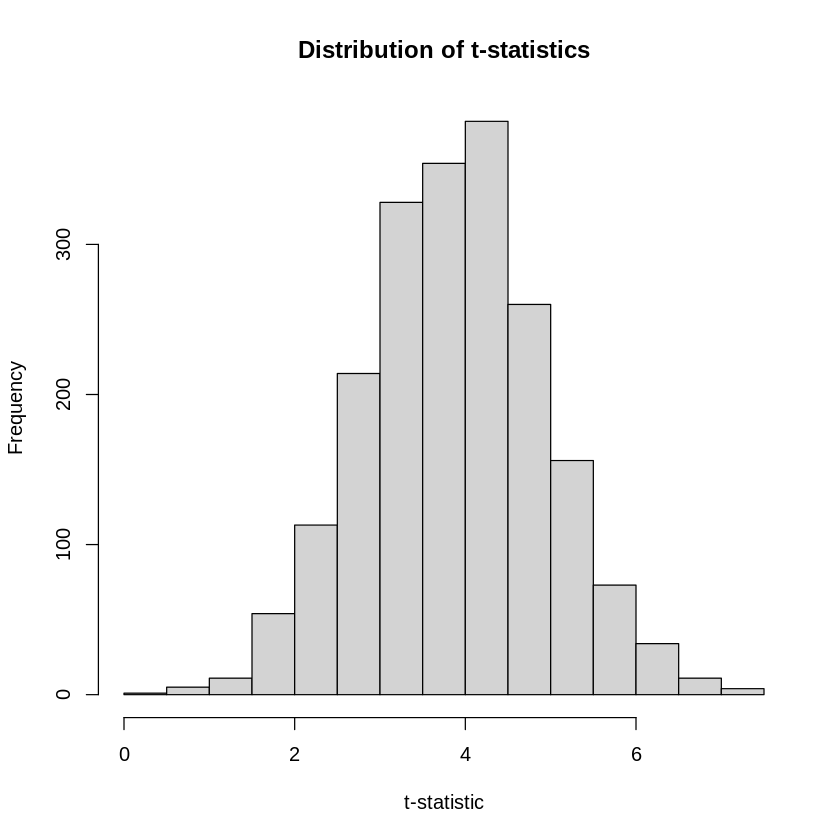

In [ ]:
set.seed(42) # Reset the seed before the simulation
#Monte Carlo replications
M = 2000

# List of the results
rej_clus = numeric(M)
t_test_val = numeric(M)

for (i in 1:M){
  df = generate_data(25, 18, 5000, 0.2, 0.25)
  regress = lm(y ~ x, data = df)
  clust_se = vcovCL(regress, cluster = ~ class_id)
  t_test_clus = coeftest(regress, vcov = clust_se)
  t_test_val[i] = t_test_clus["x", "t value"]
  rej_clus[i] = ifelse(t_test_clus["x", "Pr(>|t|)"] < 0.05, 1, 0)
}
power = mean(rej_clus)
power

# Plot the distribution of t-statistics
hist(t_test_val, main = "Distribution of t-statistics", xlab = "t-statistic")

# f)

In [ ]:
alpha = 0.05
beta = 1 - alpha
Z_alpha = qnorm(1 - alpha/2)
Z_beta = qnorm(beta)
rho = 0.2
delta = 0.25
m = (25+18)/2

n = 4*(((Z_alpha + Z_beta)^2)/delta^2)*(1+(m-1)*rho)
n = ceiling(n)
n

[1] 4242

# G)

In [ ]:
# To answer the question we first need to adapt the simulation of the data

# Creating a modified function
generate_data_2 <- function(size_regular_class, size_reduced_class, num_students, rho, delta) {
  # size_regular_class: Number of students in a regular class
  # size_reduced_class: Number of students in a reduced-size class
  # num_students: Number of students in the RCT
  # rho: Intraclass correlation coefficient
  # delta: Treatment effect in standard deviation units

  # Defining the variances of class-specific and student-specific shocks
  var_class <- rho
  var_student <- 1 - rho - (delta ^ 2) / 4

  # Defining the updated treatment status
  x <- rbinom(n = num_students, size = 1, prob = 0.3)

  # We now separate the students into treatment and control groups
  num_students_t <- sum(x == 1)
  num_students_c <- sum(x == 0)

  # Calculating # of regular classes and assigning IDs
  num_classes_c <- ceiling(num_students_c / size_regular_class)
  class_id_c <- rep(1 : num_classes_c, each = size_regular_class)[1:num_students_c]

  # Calculating # of reduced classes and assigning IDs
  num_classes_t <- ceiling(num_students_t / size_reduced_class)
  class_id_t <- rep((1 : num_classes_t) + num_classes_c, each = size_reduced_class)[1:num_students_t]

  # Combining the class IDs to have a single column
  class_id <- ifelse(x == 0, class_id_c, class_id_t)

  # Class and student specific shocks
  class_shock <- rnorm(n = length(unique(class_id)), mean = 0, sd = sqrt(var_class))
  student_shock <- rnorm(num_students, 0, sqrt(var_student))

  # Generating the test scores
  y <- delta * x + class_shock[class_id] + student_shock

  # Returning the dataset
  dataset <- data.frame(student_id = 1 : num_students, class_id = class_id, y = y, x = x)
  return(dataset)

}

In [ ]:
set.seed(42) # Reset the seed before the simulation
# We also need to find the new sample size
# Before, we had 2500 students in reduced-class sizes and we have to keep it that way

n_new = ceiling(2500/0.3)

# Preparing to run Monte Carlo simulations to test the power of the experiment
M = 2000

res_adj = numeric(M)

# Running the simulation
for (i in 1:M){
  df = generate_data_2(25, 18, n_new, 0.2, 0.25)
  regress = lm(y ~ x, data = df)
  clust_se = vcovCL(regress, cluster = ~ class_id)
  t_test_clus = coeftest(regress, vcov = clust_se)
  res_adj[i] = ifelse(t_test_clus["x", "Pr(>|t|)"] < 0.05, 1, 0)
}
power = mean(res_adj)
power

[1] 0.995

# Task 2

Loading the car library might take a few minutes, please be patient…😔

In [ ]:
# Installing previously not used libraries
install.packages("car") #Used for F tests
install.packages('lmtest')
install.packages('sandwich')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘cowplot’, ‘Deriv’, ‘microbenchmark’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Loading necesary libraries
library(readr)
library(lmtest)
library(sandwich)
library(dplyr)
library(car)

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




In [ ]:
# Importing the STAR dataset
dataset <- read.csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQ564lNnADl4cxDO9G6sV6lpP09dOf2iaXFfohfm2ZHfcJTYnuw_rDjRWNu_nX8McsHItjWgQCb0yvu/pub?gid=1480089760&single=true&output=csv",
                    header = TRUE)

# Display the first few rows of the data
head(dataset)

,stark,star1,star2,star3,totexpk,treadssk,tmathssk,totexp1,treadss1,tmathss1,⋯,ra2,ra3,white,black,other,boy,freelunk,freelun1,freelun2,freelun3
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,2,2,2,1,NA,NA,NA,NA,NA,NA,⋯,NA,0,0,1,0,0,NA,NA,NA,1
2,1,1,1,1,7,447,473,7,507,538,⋯,0,0,1,0,0,0,0,1,0,1
3,1,1,1,1,21,450,536,32,579,592,⋯,1,1,0,1,0,0,0,NA,0,0
4,2,2,2,1,NA,NA,NA,NA,NA,NA,⋯,NA,0,1,0,0,1,NA,NA,NA,0
5,1,2,2,2,0,439,463,NA,NA,NA,⋯,NA,NA,0,1,0,1,1,NA,NA,NA
6,2,2,1,1,NA,NA,NA,NA,NA,NA,⋯,0,0,1,0,0,1,NA,NA,0,0


# a)

Running the regressios for K-3 grades

In [ ]:
## K
regression_k <- lm(tscorek ~ sck + rak, data = dataset)

# Counting the number of observations
n_k <- dataset %>%
  summarise(count = sum(!is.na(tscorek)))

## 1
regression_1 <- lm(tscore1 ~ sc1 + ra1, data = dataset)

# Counting the number of observations
n_1 <- dataset %>%
  summarise(count = sum(!is.na(tscore1)))

## 2
regression_2 <- lm(tscore2 ~ sc2 + ra2, data = dataset)

# Counting the number of observations
n_2 <- dataset %>%
  summarise(count = sum(!is.na(tscore2)))

## 3
regression_3 <- lm(tscore3 ~ sc3 + ra3, data = dataset)

# Counting the number of observations
n_3 <- dataset %>%
  summarise(count = sum(!is.na(tscore3)))

Creating the table resembling 13.1 in SW textbook



In [ ]:
extract_val = function(model, school) {
  coefs = summary(model)$coefficients
  # Creating a way to tell R how to use argument for clustering
  Clu_way = as.formula(paste("~", school))
  clust_se = vcovCL(model, cluster = Clu_way) #The standard errors are clustered at the school level

  #Number of schools
  n_clusters = length(unique(dataset[[school]]))

  conf_int = coefci(model, vcov = clust_se, level = 0.95, df = n_clusters - 1) #The confindence interval calculation

data.frame(
  Regressor = rownames(coefs),
  Estimate = coefs[, "Estimate"],
  StdError = sqrt(diag(clust_se)),
  CI_Lower = ifelse(rownames(coefs) == "(Intercept)", NA, round(conf_int[, 1], 2)),
  CI_Upper = ifelse(rownames(coefs) == "(Intercept)", NA, round(conf_int[, 2], 2))
  )
}

In [ ]:
#List of regression models and school IDs
models = list(regression_k, regression_1, regression_2, regression_3)
school_ids = c("schidkn", "schid1n", "schid2n", "schid3n")

#Creating a list for all of the data
results = list()
for (i in 1:length(models)){
  results[[i]] = extract_val(models[[i]], school_ids[i])
}

#Creating a table of the data
combined_results = data.frame(
  Regressor = results[[1]]$Regressor,
  K = ifelse(is.na(results[[1]]$CI_Lower),
              paste0(round(results[[1]]$Estimate, 2), " (", round(results[[1]]$StdError, 2), ")"), # Format for Intercept
              paste0(round(results[[1]]$Estimate, 2), " (", round(results[[1]]$StdError, 2), ") [", round(results[[1]]$CI_Lower, 2), ", ", round(results[[1]]$CI_Upper, 2), "]")  # Format for others
  ),
  '1' = ifelse(is.na(results[[2]]$CI_Lower),
              paste0(round(results[[2]]$Estimate, 2), " (", round(results[[2]]$StdError, 2), ")"),
              paste0(round(results[[2]]$Estimate, 2), " (", round(results[[2]]$StdError, 2), ") [", round(results[[2]]$CI_Lower, 2), ", ", round(results[[2]]$CI_Upper, 2), "]")
  ),
  '2' = ifelse(is.na(results[[3]]$CI_Lower),
              paste0(round(results[[3]]$Estimate, 2), " (", round(results[[3]]$StdError, 2), ")"),
              paste0(round(results[[3]]$Estimate, 2), " (", round(results[[3]]$StdError, 2), ") [", round(results[[3]]$CI_Lower, 2), ", ", round(results[[3]]$CI_Upper, 2), "]")
  ),
  '3' = ifelse(is.na(results[[4]]$CI_Lower),
              paste0(round(results[[4]]$Estimate, 2), " (", round(results[[4]]$StdError, 2), ")"),
              paste0(round(results[[4]]$Estimate, 2), " (", round(results[[4]]$StdError, 2), ") [", round(results[[4]]$CI_Lower, 2), ", ", round(results[[4]]$CI_Upper, 2), "]")
  ))

combined_results = rbind(
  combined_results,
  data.frame(
    Regressor = "N",
    K = n_k$count,
    '1' = format(n_1$count, nsmall = 0),
    '2' = format(n_2$count, nsmall = 0),
    '3' = format(n_3$count, nsmall = 0)
  )
)

#Renaming the rows
combined_results$Regressor = factor(combined_results$Regressor,
                                     levels = c("(Intercept)", "sck", "rak", "N"),
                                     labels = c("Intercept", "Small Class", "Regular with Aide", "Number of observations"))

combined_results


Regressor,K,X1,X2,X3
<fct>,<chr>,<chr>,<chr>,<chr>
Intercept,918.04 (4.82),1039.39 (5.82),1157.81 (5.29),1228.51 (4.66)
Small Class,"13.9 (4.23) [5.48, 22.32]","29.78 (4.79) [20.25, 39.31]","19.39 (5.12) [9.19, 29.6]","15.59 (4.21) [7.21, 23.96]"
Regular with Aide,"0.31 (3.77) [-7.19, 7.82]","11.96 (4.86) [2.28, 21.64]","3.48 (4.91) [-6.3, 13.26]","-0.29 (4.04) [-8.34, 7.76]"
Number of observations,5786,6379,6049,5967


Running the regressions for grade K, now adding more variables

In [ ]:
## Regression (1)
clust_se_K = vcovCL(regression_k, cluster = ~ schidkn, df = (n_clusters_k - 1))
conf_int_K = coefci(regression_k, vcov = clust_se_K, level = 0.95)

# Coefficients were obtained in the previous part, only adjusted R squared remains
r_sqr_K1 = round(summary(regression_k)$adj.r.squared, 2)

In [ ]:
## Regression (2)
regression_K2 = lm(tscorek ~ sck + rak + totexpk, data = dataset)

# The standard errors are clustered at the school level
n_clusters_k = length(unique(dataset[["schidkn"]]))
clust_se_K2 = vcovCL(regression_K2, cluster = ~ schidkn, df = (n_clusters_k - 1))

# t test of coefficients with clustered errors
coeftest(regression_K2, vcov = clust_se_K2)

# Confidence intervals with clustered errors
conf_int_K2 = coefci(regression_K2, vcov = clust_se_K2, level = 0.95)

# Counting the number of observations
n_K2 <- dataset %>%
  summarise(count = sum(!is.na(tscorek) & !is.na(totexpk)))

# Adjusted R squared
r_sqr_K2 = round(summary(regression_K2)$adj.r.squared, 2)



t test of coefficients:

             Estimate Std. Error  t value  Pr(>|t|)    
(Intercept) 904.72124    6.20416 145.8250 < 2.2e-16 ***
sck          14.00613    4.24559   3.2990 0.0009762 ***
rak          -0.60058    3.84065  -0.1564 0.8757427    
totexpk       1.46903    0.43781   3.3554 0.0007976 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [ ]:
## Regression (3)
regression_K3 <- lm(tscorek ~ sck + rak + totexpk + factor(schidkn), data = dataset)

# The standard errors are clustered at the school level
n_clusters_k = length(unique(dataset[["schidkn"]]))
clust_se_K3 = vcovCL(regression_K3, cluster = ~ schidkn, df = (n_clusters_k - 1), type = "HC0")

# t test of coefficients with clustered errors
coeftest(regression_K3, vcov = clust_se_K3)

# Confidence intervals with clustered errors
conf_int_K3 = coefci(regression_K3, vcov = clust_se_K3, level = 0.95)

# Counting the number of observations
n_K3 <- dataset %>%
  summarise(count = sum(!is.na(tscorek) & !is.na(totexpk)))

# Adjusted R squared
r_sqr_K3 = round(summary(regression_K3)$adj.r.squared, 2)


t test of coefficients:

                    Estimate Std. Error   t value  Pr(>|t|)    
(Intercept)        925.67488    3.57304  259.0719 < 2.2e-16 ***
sck                 15.93308    4.07866    3.9065 9.475e-05 ***
rak                  1.21520    3.64304    0.3336 0.7387189    
totexpk              0.74311    0.35384    2.1001 0.0357650 *  
factor(schidkn)2   -81.71570    0.97862  -83.5008 < 2.2e-16 ***
factor(schidkn)3    -7.17502    1.15247   -6.2258 5.135e-10 ***
factor(schidkn)4   -44.73533    1.36307  -32.8194 < 2.2e-16 ***
factor(schidkn)5   -48.42507    0.65751  -73.6489 < 2.2e-16 ***
factor(schidkn)6   -38.44128    0.82011  -46.8734 < 2.2e-16 ***
factor(schidkn)7    22.67165    1.22345   18.5310 < 2.2e-16 ***
factor(schidkn)8   -34.50473    0.94768  -36.4099 < 2.2e-16 ***
factor(schidkn)9     4.03172    0.63466    6.3525 2.282e-10 ***
factor(schidkn)10   38.55819    0.58596   65.8030 < 2.2e-16 ***
factor(schidkn)11   57.98142    0.97240   59.6272 < 2.2e-16 ***
factor(schidkn

In [ ]:
regression_K4 <- lm(tscorek ~ sck + rak + totexpk + boy + freelunk + black + other + factor(schidkn), data = dataset)

# The standard errors are clustered at the school level
clust_se_K4 = vcovCL(regression_K4, cluster = ~ schidkn, type = "HC0")

# Confidence intervals with clustered errors
conf_int_K4 = coefci(regression_K4, vcov = clust_se_K4, level = 0.95)

# Counting the number of observations
n_K4 <- dataset %>%
  summarise(count = sum(!is.na(tscorek) & !is.na(totexpk) & !is.na(freelunk) & !is.na(black)))

# Adjusted R squared
r_sqr_K4 = round(summary(regression_K4)$adj.r.squared, 2)


In [ ]:
# Putting together a data frame for a table
# Create the data frame with extracted values
coefs_K = summary(regression_k)$coefficients
coefs_K2 = summary(regression_K2)$coefficients
coefs_K3 = summary(regression_K3)$coefficients
coefs_K4 = summary(regression_K4)$coefficients

Table13_2 <- data.frame(
  Regressor = c("Small class", "Regular-sized class with aide", "Teacher’s years of experience", "Boy", "Free lunch eligible", "Black", "Race other than black or white", "School indicator variables?", "R²", "Number of observations"),
  "(1)" = c(
    paste0(round(coefs_K["sck", "Estimate"], 2), " (", round(sqrt(diag(clust_se_K))["sck"], 2), ") [", round(conf_int_K["sck", 1], 2), ", ", round(conf_int_K["sck", 2], 2), "]"),
    paste0(round(coefs_K["rak", "Estimate"], 2), " (", round(sqrt(diag(clust_se_K))["rak"], 2), ") [", round(conf_int_K["rak", 1], 2), ", ", round(conf_int_K["rak", 2], 2), "]"),
    NA, NA, NA, NA, NA, "no",
    round(r_sqr_K1, 2), n_1$count
  ),
  "(2)" = c(
    paste0(round(coefs_K2["sck", "Estimate"], 2), " (", round(sqrt(diag(clust_se_K2))["sck"], 2), ") [", round(conf_int_K2["sck", 1], 2), ", ", round(conf_int_K2["sck", 2], 2), "]"),
    paste0(round(coefs_K2["rak", "Estimate"], 2), " (", round(sqrt(diag(clust_se_K2))["rak"], 2), ") [", round(conf_int_K2["rak", 1], 2), ", ", round(conf_int_K2["rak", 2], 2), "]"),
    paste0(round(coefs_K2["totexpk", "Estimate"], 2), " (", round(sqrt(diag(clust_se_K2))["totexpk"], 2), ") [", round(conf_int_K2["totexpk", 1], 2), ", ", round(conf_int_K2["totexpk", 2], 2), "]"),
    NA, NA, NA, NA, "no",
    round(r_sqr_K2, 2), n_K2$count
  ),
  "(3)" = c(
    paste0(round(coefs_K3["sck", "Estimate"], 2), " (", round(sqrt(diag(clust_se_K3))["sck"], 2), ") [", round(conf_int_K3["sck", 1], 2), ", ", round(conf_int_K3["sck", 2], 2), "]"),
    paste0(round(coefs_K3["rak", "Estimate"], 2), " (", round(sqrt(diag(clust_se_K3))["rak"], 2), ") [", round(conf_int_K3["rak", 1], 2), ", ", round(conf_int_K3["rak", 2], 2), "]"),
    paste0(round(coefs_K3["totexpk", "Estimate"], 2), " (", round(sqrt(diag(clust_se_K3))["totexpk"], 2), ") [", round(conf_int_K3["totexpk", 1], 2), ", ", round(conf_int_K3["totexpk", 2], 2), "]"),
    NA, NA, NA, NA, "yes",
    round(r_sqr_K3, 2), n_K3$count
  ),
  "(4)" = c(
    paste0(round(coefs_K4["sck", "Estimate"], 2), " (", round(sqrt(diag(clust_se_K4))["sck"], 2), ") [", round(conf_int_K4["sck", 1], 2), ", ", round(conf_int_K4["sck", 2], 2), "]"),
    paste0(round(coefs_K4["rak", "Estimate"], 2), " (", round(sqrt(diag(clust_se_K4))["rak"], 2), ") [", round(conf_int_K4["rak", 1], 2), ", ", round(conf_int_K4["rak", 2], 2), "]"),
    paste0(round(coefs_K4["totexpk", "Estimate"], 2), " (", round(sqrt(diag(clust_se_K4))["totexpk"], 2), ") [", round(conf_int_K4["totexpk", 1], 2), ", ", round(conf_int_K4["totexpk", 2], 2), "]"),
    paste0(round(coefs_K4["boy", "Estimate"], 2), " (", round(sqrt(diag(clust_se_K4))["boy"], 2), ")"),
    paste0(round(coefs_K4["freelunk", "Estimate"], 2), " (", round(sqrt(diag(clust_se_K4))["freelunk"], 2), ")"),
    paste0(round(coefs_K4["black", "Estimate"], 2), " (", round(sqrt(diag(clust_se_K4))["black"], 2), ")"),
    paste0(round(coefs_K4["other", "Estimate"], 2), " (", round(sqrt(diag(clust_se_K4))["other"], 2), ")"),
    "yes",
    round(r_sqr_K4, 2), n_K4$count
  )
)
Table13_2

Regressor,X.1.,X.2.,X.3.,X.4.
<chr>,<chr>,<chr>,<chr>,<chr>
Small class,"13.9 (4.23) [5.6, 22.19]","14.01 (4.25) [5.68, 22.33]","15.93 (4.08) [7.94, 23.93]","15.89 (3.94) [8.16, 23.62]"
Regular-sized class with aide,"0.31 (3.77) [-7.08, 7.7]","-0.6 (3.84) [-8.13, 6.93]","1.22 (3.64) [-5.93, 8.36]","1.79 (3.6) [-5.27, 8.84]"
Teacher’s years of experience,NA,"1.47 (0.44) [0.61, 2.33]","0.74 (0.35) [0.05, 1.44]","0.66 (0.36) [-0.04, 1.36]"
Boy,NA,NA,NA,-12.09 (1.54)
Free lunch eligible,NA,NA,NA,-34.7 (2.46)
Black,NA,NA,NA,-25.43 (4.52)
Race other than black or white,NA,NA,NA,-8.5 (12.63)
School indicator variables?,no,no,yes,yes
R²,0.01,0.02,0.22,0.28


# b)

In [ ]:
# Regression of boy on variables

regression_b <- lm(boy ~ sck + rak, data = dataset)

# The standard errors are clustered at the school level
clust_se_b <- vcovCL(regression_b, cluster = ~ schidkn, df = (n_clusters_k - 1))

# F test of coefficients with clustered errors
F_test_b = linearHypothesis(regression_b, c("sck = 0", "rak = 0"), vcov = clust_se_b)

In [ ]:
# Regression of qualification for free lunch
regression_l <- lm(freelunk ~ sck + rak, data = dataset)

# The standard errors are clustered at the school level
clust_se_l <- vcovCL(regression_l, cluster = ~ schidkn, df = (n_clusters_k - 1))

# F test of coefficients with clustered errors
F_test_l = linearHypothesis(regression_l, c("sck = 0", "rak = 0"), vcov = clust_se_l)

In [ ]:
# Regression of white
regression_w <- lm(white ~ sck + rak, data = dataset)

# The standard errors are clustered at the school level
clust_se_w <- vcovCL(regression_w, cluster = ~ schidkn, df = (n_clusters_k - 1))

# F test of coefficients with clustered errors
F_test_w = linearHypothesis(regression_w, c("sck = 0", "rak = 0"), vcov = clust_se_w)

In [ ]:
# Create a data frame to store the results
results_table_b = data.frame(
  Regression = c("boy", "freelunk", "white"),
  F_statistic = c(F_test_b$F[2], F_test_l$F[2], F_test_w$F[2]), # Extract F-statistic
  p_value = c(F_test_b$"Pr(>F)"[2], F_test_l$"Pr(>F)"[2], F_test_w$"Pr(>F)"[2]) # Extract p-value
)

# Display the table
print(results_table_b)

  Regression F_statistic   p_value
1        boy   0.1449448 0.8650729
2   freelunk   2.0805548 0.1249467
3      white   0.7019601 0.4956515


# C)

In [ ]:
# Variables for number of students in kindergarden for each condition
nrow_sck <- nrow (dataset %>% filter(sck == 1))
nrow_rak <- nrow (dataset %>% filter(rak == 1))
nrow_rk <- nrow (dataset %>% filter(rak == 0 & sck == 0))

# Variables for number of students that remained in the condition from kinergarden to 3rd grade
remaining_sc <- nrow (dataset %>% filter(sck == 1 & sc3 == 1))
remaining_ra <- nrow (dataset %>% filter(rak == 1 & ra3 == 1))
remaining_r <- nrow (dataset %>% filter(rak == 0 & ra3 == 0 & sck == 0 & sc3 == 0))

# Calculating percentages
percentage_sc <- (remaining_sc/nrow_sck)*100
percentage_ra <- (remaining_ra/nrow_rak)*100
percentage_r <- (remaining_r/nrow_rk)*100

print("Percentage - small class:")
percentage_sc
print("Percentage - regular class with aide:")
percentage_ra
print("Percentage - regular class:")
percentage_r

# Adding variables to a vector
data_attrition <- c(remaining_r, remaining_ra, remaining_sc)

# Chi-square test
chisq_test <- chisq.test(data_attrition)
print(chisq_test)


[1] "Percentage - small class:"


[1] 46.89474

[1] "Percentage - regular class with aide:"


[1] 24.38368

[1] "Percentage - regular class:"


[1] 18.91522


	Chi-squared test for given probabilities

data:  data_attrition
X-squared = 196.55, df = 2, p-value < 2.2e-16



D)

In [ ]:
# Create a subsample

data_subsample <- dataset %>%
  filter (stark == 1 & star1 == 1 & star2 == 1 & star3 == 1)

head (data_subsample)


,stark,star1,star2,star3,totexpk,treadssk,tmathssk,totexp1,treadss1,tmathss1,⋯,ra2,ra3,white,black,other,boy,freelunk,freelun1,freelun2,freelun3
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,1,1,1,1,7,447,473,7,507,538,⋯,0,0,1,0,0,0,0,1,0,1
2,1,1,1,1,21,450,536,32,579,592,⋯,1,1,0,1,0,0,0,NA,0,0
3,1,1,1,1,16,448,559,11,651,584,⋯,0,0,1,0,0,1,0,0,0,0
4,1,1,1,1,5,447,489,15,533,545,⋯,0,0,1,0,0,1,1,1,1,1
5,1,1,1,1,8,431,454,0,558,553,⋯,0,0,1,0,0,1,1,NA,1,1
6,1,1,1,1,3,451,500,5,548,567,⋯,0,0,1,0,0,0,0,1,1,1


In [ ]:
# Replicating table 13.1 with the subsample (as in part A)

## K
regression_k <- lm(tscorek ~ sck + rak, data = data_subsample)

# Counting the number of observations
n_k <- data_subsample %>%
  summarise(count = sum(!is.na(tscorek)))

## 1
regression_1 <- lm(tscore1 ~ sc1 + ra1, data = data_subsample)

# Counting the number of observations
n_1 <- data_subsample %>%
  summarise(count = sum(!is.na(tscore1)))

## 2
regression_2 <- lm(tscore2 ~ sc2 + ra2, data = data_subsample)

# Counting the number of observations
n_2 <- data_subsample %>%
  summarise(count = sum(!is.na(tscore2)))

## 3
regression_3 <- lm(tscore3 ~ sc3 + ra3, data = data_subsample)

# Counting the number of observations
n_3 <- data_subsample %>%
  summarise(count = sum(!is.na(tscore3)))

extract_val = function(model, school) {
  coefs = summary(model)$coefficients
  # Creating a way to tell R how to use argument for clustering
  Clu_way = as.formula(paste("~", school))
  clust_se = vcovCL(model, cluster = Clu_way) #The standard errors are clustered at the school level

  #Number of schools
  n_clusters = length(unique(data_subsample[[school]]))

  conf_int = coefci(model, vcov = clust_se, level = 0.95, df = n_clusters - 1) #The confindence interval calculation

data.frame(
  Regressor = rownames(coefs),
  Estimate = coefs[, "Estimate"],
  StdError = sqrt(diag(clust_se)),
  CI_Lower = ifelse(rownames(coefs) == "(Intercept)", NA, round(conf_int[, 1], 2)),
  CI_Upper = ifelse(rownames(coefs) == "(Intercept)", NA, round(conf_int[, 2], 2))
  )
}

#List of regression models and school IDs
models = list(regression_k, regression_1, regression_2, regression_3)
school_ids = c("schidkn", "schid1n", "schid2n", "schid3n")

#Creating a list for all of the data
results = list()
for (i in 1:length(models)){
  results[[i]] = extract_val(models[[i]], school_ids[i])
}

#Creating a table of the data
combined_results = data.frame(
  Regressor = results[[1]]$Regressor,
  K = ifelse(is.na(results[[1]]$CI_Lower),
              paste0(round(results[[1]]$Estimate, 2), " (", round(results[[1]]$StdError, 2), ")"), # Format for Intercept
              paste0(round(results[[1]]$Estimate, 2), " (", round(results[[1]]$StdError, 2), ") [", round(results[[1]]$CI_Lower, 2), ", ", round(results[[1]]$CI_Upper, 2), "]")  # Format for others
  ),
  '1' = ifelse(is.na(results[[2]]$CI_Lower),
              paste0(round(results[[2]]$Estimate, 2), " (", round(results[[2]]$StdError, 2), ")"),
              paste0(round(results[[2]]$Estimate, 2), " (", round(results[[2]]$StdError, 2), ") [", round(results[[2]]$CI_Lower, 2), ", ", round(results[[2]]$CI_Upper, 2), "]")
  ),
  '2' = ifelse(is.na(results[[3]]$CI_Lower),
              paste0(round(results[[3]]$Estimate, 2), " (", round(results[[3]]$StdError, 2), ")"),
              paste0(round(results[[3]]$Estimate, 2), " (", round(results[[3]]$StdError, 2), ") [", round(results[[3]]$CI_Lower, 2), ", ", round(results[[3]]$CI_Upper, 2), "]")
  ),
  '3' = ifelse(is.na(results[[4]]$CI_Lower),
              paste0(round(results[[4]]$Estimate, 2), " (", round(results[[4]]$StdError, 2), ")"),
              paste0(round(results[[4]]$Estimate, 2), " (", round(results[[4]]$StdError, 2), ") [", round(results[[4]]$CI_Lower, 2), ", ", round(results[[4]]$CI_Upper, 2), "]")
  ))

combined_results = rbind(
  combined_results,
  data.frame(
    Regressor = "N",
    K = n_k$count,
    '1' = format(n_1$count, nsmall = 0),
    '2' = format(n_2$count, nsmall = 0),
    '3' = format(n_3$count, nsmall = 0)
  )
)

#Renaming the rows
combined_results$Regressor = factor(combined_results$Regressor,
                                     levels = c("(Intercept)", "sck", "rak", "N"),
                                     labels = c("Intercept", "Small Class", "Regular with Aide", "Number of observations"))

combined_results

Regressor,K,X1,X2,X3
<fct>,<chr>,<chr>,<chr>,<chr>
Intercept,938.56 (4.97),1072.79 (6.14),1180.94 (5.36),1247.32 (4.51)
Small Class,"14.02 (4.36) [5.32, 22.71]","20.55 (5.09) [10.41, 30.69]","13.69 (5.39) [2.96, 24.43]","9.98 (4.3) [1.41, 18.54]"
Regular with Aide,"-2.37 (4.42) [-11.18, 6.44]","6.53 (5.84) [-5.11, 18.16]","5.41 (5.66) [-5.88, 16.69]","0.86 (4.54) [-8.19, 9.91]"
Number of observations,2892,2974,2974,2882


E)

In [ ]:
# Estimator for grade K
impact_k <- regression_k$coefficients[["sck"]]

# Estimator for grade 1
impact_1 <- regression_1$coefficients[["sc1"]]

# Estimator for grade 2
impact_2 <- regression_2$coefficients[["sc2"]]

# Estimator for grade 3
impact_3 <- regression_3$coefficients[["sc3"]]

impact_k
impact_1
impact_2
impact_3

[1] 14.01609

[1] 20.5537

[1] 13.69489

[1] 9.977523

F)

In [ ]:
# Scenario K
impact_on_scores_K = round(0.625 * impact_k, 2)
impact_on_scores_K

# Scenario K-3
impact_1 = 0.625 * impact_1
impact_2 = 0.625 * impact_2
impact_3 = 0.625 * impact_3

impact_on_scores_K3 = round(sum(impact_on_scores_K, impact_1, impact_2, impact_3), 2)
impact_on_scores_K3

[1] 8.76

[1] 36.4

G)

In [ ]:
# Calculating the expected increases in earnings under our assumptions
ProjectSTAREff = 0.02
per_inc_K = ProjectSTAREff * 0.625

per_inc_K3 = (impact_on_scores_K3/impact_on_scores_K) * per_inc_K

# Create a table for the earnings
student_age <- 25:65
baseline_earnings <- c(rep(50000, length(student_age)))
extra_earnings_k <- rep(round(50000*per_inc_K, 2), length(student_age))
extra_earnings_k3 <- c(rep(round(50000*per_inc_K3, 2), length(student_age)))

# Scenario K
extra_earnings_table_k <- data.frame(
  Student_Age = student_age,
  Baseline_Earnings = baseline_earnings,
  Extra_Earnings = extra_earnings_k)

# Scenario K-3
extra_earnings_table_k3 <- data.frame(
  Student_Age = student_age,
  Baseline_Earnings = baseline_earnings,
  Extra_Earnings = extra_earnings_k3)

# Print the table
print("Yearly Extra Earnings per Person for Reduced Class Sizes for scenario K")
print(extra_earnings_table_k)
print("Yearly Extra Earnings per Person for Reduced Class Sizes for scenario K-3")
print(extra_earnings_table_k3)

[1] "Yearly Extra Earnings per Person for Reduced Class Sizes for scenario K"
   Student_Age Baseline_Earnings Extra_Earnings
1           25             50000            625
2           26             50000            625
3           27             50000            625
4           28             50000            625
5           29             50000            625
6           30             50000            625
7           31             50000            625
8           32             50000            625
9           33             50000            625
10          34             50000            625
11          35             50000            625
12          36             50000            625
13          37             50000            625
14          38             50000            625
15          39             50000            625
16          40             50000            625
17          41             50000            625
18          42             50000            625
19        

H)

In [ ]:
# Constants
teacher_cost <- 100000          # Cost of one extra teacher per year
original_class_size <- 25       # Original class size
small_class_size <- 20          # Reduced class size
cost_per_student_original <- teacher_cost / original_class_size
cost_per_student_reduced <- teacher_cost / small_class_size
extra_cost_per_student <- cost_per_student_reduced - cost_per_student_original
extra_cost_per_class <- extra_cost_per_student * original_class_size

# Create a table for the costs
student_age <- 6:65                                # Ages from kindergarten to retirement
years <- 0:(length(student_age) - 1)               # Years relative to kindergarten
extra_cost_k <- c(round(extra_cost_per_class, 2), rep(0, length (student_age) - 1))
extra_cost_k3 <- c(rep(round(extra_cost_per_class, 2), 4), rep(0, length (student_age) - 4))

# Scenario K
extra_cost_table_k <- data.frame(
  Year = years,
  Student_Age = student_age,
  Extra_Cost = extra_cost_k)

# Scenario K-3
extra_cost_table_k3 <- data.frame(
  Year = years,
  Student_Age = student_age,
  Extra_Cost = extra_cost_k3)

# Print the table
print("Yearly Extra Costs per Class for Reduced Class Sizes for scenario K")
print(extra_cost_table_k)
print("Yearly Extra Costs per Class for Reduced Class Sizes for scenario K-3")
print(extra_cost_table_k3)

[1] "Yearly Extra Costs per Class for Reduced Class Sizes for scenario K"
   Year Student_Age Extra_Cost
1     0           6      25000
2     1           7          0
3     2           8          0
4     3           9          0
5     4          10          0
6     5          11          0
7     6          12          0
8     7          13          0
9     8          14          0
10    9          15          0
11   10          16          0
12   11          17          0
13   12          18          0
14   13          19          0
15   14          20          0
16   15          21          0
17   16          22          0
18   17          23          0
19   18          24          0
20   19          25          0
21   20          26          0
22   21          27          0
23   22          28          0
24   23          29          0
25   24          30          0
26   25          31          0
27   26          32          0
28   27          33          0
29   28          34        

I)

In [ ]:
# Create a table for the cost-benefit analysis
r <- 3
student_age <- 6:65
years <- 0:(length(student_age) - 1)
cost_k <- extra_cost_k
cost_k3 <- extra_cost_k3
benefit_k <- c(rep(0, 25-6), extra_earnings_k * 25) #Multiplying by 25 to get extra earnings for the whole class
benefit_k3 <- c(rep(0, 25-6), extra_earnings_k3 * 25)
disc_factor <- 1/(1+r)^years
disc_cost_k <- cost_k * disc_factor
disc_benefit_k <- benefit_k * disc_factor
disc_cost_k3 <- cost_k3 * disc_factor
disc_benefit_k3 <- benefit_k3 * disc_factor

# Scenario K
cost_benefit_table_k <- data.frame(
  Year = years,
  Student_Age = student_age,
  Cost = cost_k,
  Benefit = benefit_k,
  Discount_Factor = format(disc_factor, scientific = TRUE, digits = 2),
  Discounted_Cost = disc_cost_k,
  Discounted_Benefit = format(disc_benefit_k, scientific = TRUE, digits = 2))

# Scenario K-3
cost_benefit_table_k3 <- data.frame(
  Year = years,
  Student_Age = student_age,
  Cost = cost_k3,
  Benefit = benefit_k3,
  Discount_Factor = format(disc_factor, scientific = TRUE, digits = 2),
  Discounted_Cost = disc_cost_k3,
  Discounted_Benefit = format(disc_benefit_k3, scientific = TRUE, digits = 2))

# Printing the tables
print("Cost-Benefit Analysis for Reduced Class Sizes for scenario K")
print (cost_benefit_table_k)
print("Cost-Benefit Analysis for Reduced Class Sizes for scenario K-3")
print (cost_benefit_table_k3)

# Calculating benefit-to-cost ratios
sum_cost_k <- sum(disc_cost_k)
sum_benefit_k <- sum(disc_benefit_k)
sum_cost_k3 <- sum(disc_cost_k3)
sum_benefit_k3 <- sum(disc_benefit_k3)
benefit_to_cost_k <- sum_benefit_k / sum_cost_k
benefit_to_cost_k3 <- sum_benefit_k3 / sum_cost_k3

# Printing benefit-to-cost ratios
print("Benefit-to-Cost ratio for scenario K")
print (benefit_to_cost_k)
print("Benefit-to-Cost ratio for scenario K-3")
print (benefit_to_cost_k3)

[1] "Cost-Benefit Analysis for Reduced Class Sizes for scenario K"
   Year Student_Age  Cost Benefit Discount_Factor Discounted_Cost
1     0           6 25000       0         1.0e+00           25000
2     1           7     0       0         2.5e-01               0
3     2           8     0       0         6.2e-02               0
4     3           9     0       0         1.6e-02               0
5     4          10     0       0         3.9e-03               0
6     5          11     0       0         9.8e-04               0
7     6          12     0       0         2.4e-04               0
8     7          13     0       0         6.1e-05               0
9     8          14     0       0         1.5e-05               0
10    9          15     0       0         3.8e-06               0
11   10          16     0       0         9.5e-07               0
12   11          17     0       0         2.4e-07               0
13   12          18     0       0         6.0e-08               0
14   13  

J)

In [ ]:
# Sensitivity table setup
teacher_cost <- 100000
original_class_size <- 25
student_age <- 6:65
r_values <- 0:6                     # Discount rates
small_class_sizes <- 15:24          # Class sizes
years <- 0:(length(student_age) - 1)

results <- matrix(NA, nrow = length(small_class_sizes), ncol = length(r_values))

# Scenario K

for (i in seq_along(small_class_sizes)) {
  for (j in seq_along(r_values)) {
    small_class_size <- small_class_sizes[i]
    r <- r_values[j]

    # Updated costs
    cost_per_student_original <- teacher_cost / original_class_size
    cost_per_student_reduced <- teacher_cost / small_class_size
    extra_cost_per_student <- cost_per_student_reduced - cost_per_student_original
    extra_cost_per_class <- extra_cost_per_student * original_class_size

    # Recalculate discounted costs and benefits
    extra_cost_k <- c(round(extra_cost_per_class, 2), rep(0, length(student_age) - 1))
    benefit_k <- c(rep(0, 25-6), extra_earnings_k * 25)
    disc_factor <- 1 / (1 + r)^years
    disc_cost_k <- extra_cost_k * disc_factor
    disc_benefit_k <- benefit_k * disc_factor
    sum_cost_k <- sum(disc_cost_k)
    sum_benefit_k <- sum(disc_benefit_k)

    # Benefit-to-cost ratio
    benefit_to_cost_k <- sum_benefit_k / sum_cost_k
    results[i, j] <- format(benefit_to_cost_k, scientific = TRUE, digits = 2)  # Store result
  }
}

# Add row and column names
rownames(results) <- paste("Class Size", small_class_sizes)
colnames(results) <- paste("r =", r_values)

# Print sensitivity table
print("Sensitivity Table for Scenario K: Benefit-to-Cost Ratios")
print(results)

# Scenario K-3

for (i in seq_along(small_class_sizes)) {
  for (j in seq_along(r_values)) {
    small_class_size <- small_class_sizes[i]
    r <- r_values[j]

    # Updated costs
    cost_per_student_original <- teacher_cost / original_class_size
    cost_per_student_reduced <- teacher_cost / small_class_size
    extra_cost_per_student <- cost_per_student_reduced - cost_per_student_original
    extra_cost_per_class <- extra_cost_per_student * original_class_size

    # Recalculate discounted costs and benefits
    benefit_k3 <- c(rep(0, 25-6), extra_earnings_k * 25)
    extra_cost_k3 <- c(rep(round(extra_cost_per_class, 2), 4), rep(0, length(student_age) - 4))
    disc_factor <- 1 / (1 + r)^years
    disc_cost_k <- extra_cost_k * disc_factor
    disc_benefit_k <- benefit_k * disc_factor
    sum_cost_k <- sum(disc_cost_k)
    sum_benefit_k <- sum(disc_benefit_k)

    # Benefit-to-cost ratio
    benefit_to_cost_k <- sum_benefit_k / sum_cost_k
    results[i, j] <- format(benefit_to_cost_k, scientific = TRUE, digits = 2)  # Store result
  }
}

# Add row and column names
rownames(results) <- paste("Class Size", small_class_sizes)
colnames(results) <- paste("r =", r_values)

# Print sensitivity table
print("Sensitivity Table for Scenario K-3: Benefit-to-Cost Ratios")
print(results)


[1] "Sensitivity Table for Scenario K: Benefit-to-Cost Ratios"
              r = 0     r = 1     r = 2     r = 3     r = 4     r = 5    
Class Size 15 "9.6e+00" "8.9e-07" "3e-10"   "1.1e-12" "1.5e-14" "4.6e-16"
Class Size 16 "1.1e+01" "1.1e-06" "3.6e-10" "1.3e-12" "1.8e-14" "5.5e-16"
Class Size 17 "1.4e+01" "1.3e-06" "4.3e-10" "1.6e-12" "2.2e-14" "6.5e-16"
Class Size 18 "1.6e+01" "1.5e-06" "5.2e-10" "1.9e-12" "2.6e-14" "7.9e-16"
Class Size 19 "2e+01"   "1.9e-06" "6.4e-10" "2.4e-12" "3.2e-14" "9.7e-16"
Class Size 20 "2.6e+01" "2.4e-06" "8.1e-10" "3e-12"   "4.1e-14" "1.2e-15"
Class Size 21 "3.4e+01" "3.1e-06" "1.1e-09" "4e-12"   "5.4e-14" "1.6e-15"
Class Size 22 "4.7e+01" "4.4e-06" "1.5e-09" "5.6e-12" "7.5e-14" "2.3e-15"
Class Size 23 "7.4e+01" "6.9e-06" "2.3e-09" "8.7e-12" "1.2e-13" "3.5e-15"
Class Size 24 "1.5e+02" "1.4e-05" "4.8e-09" "1.8e-11" "2.5e-13" "7.4e-15"
              r = 6    
Class Size 15 "2.4e-17"
Class Size 16 "2.8e-17"
Class Size 17 "3.4e-17"
Class Size 18 "4.1e-17"
Cla